<a href="https://colab.research.google.com/github/ravi-0309/Dynamic-Response/blob/main/Response_of_a_Bridge_Truss_due_to_Ground_Motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Eigenvalues:
[-2.74913809e-12 -1.37291924e-12 -1.29472843e-12 -1.06430885e-12
 -2.50382704e-13 -1.71996309e-13  4.70954035e-13  5.69524179e-13
  8.21404524e-13  2.87044162e-12  1.29111676e+02  2.55878863e+02
  9.97244064e+02  1.23840717e+03  1.40801632e+03  1.43180288e+03
  1.61831120e+03  1.70314214e+03  1.72620589e+03  1.95816305e+03
  2.04217285e+03  2.22525138e+03  2.40432434e+03  2.53734279e+03
  2.79221997e+03  2.81135762e+03  3.29527963e+03  3.33553152e+03
  3.71669337e+03  4.04293387e+03  4.17918292e+03  4.59455946e+03
  5.32009637e+03  6.75518383e+03  7.70030864e+03  7.95483978e+03]

Valid Natural Frequencies (Hz):
Mode 11: 1.808 Hz
Mode 12: 2.546 Hz
Mode 13: 5.026 Hz
Mode 14: 5.601 Hz
Mode 15: 5.972 Hz
Mode 16: 6.022 Hz
Mode 17: 6.403 Hz
Mode 18: 6.568 Hz
Mode 19: 6.613 Hz
Mode 20: 7.043 Hz
Mode 21: 7.192 Hz
Mode 22: 7.508 Hz
Mode 23: 7.804 Hz
Mode 24: 8.017 Hz
Mode 25: 8.410 Hz
Mode 26: 8.439 Hz
Mode 27: 9.136 Hz
Mode 28: 9.192 Hz
Mode 29: 9.703 Hz
Mode 30: 10.120 Hz
Mode 3

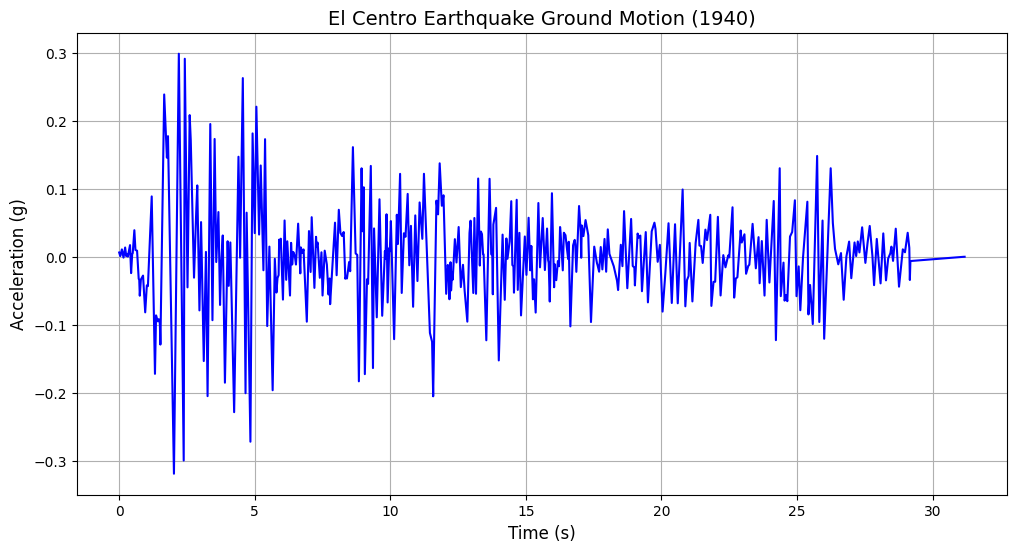

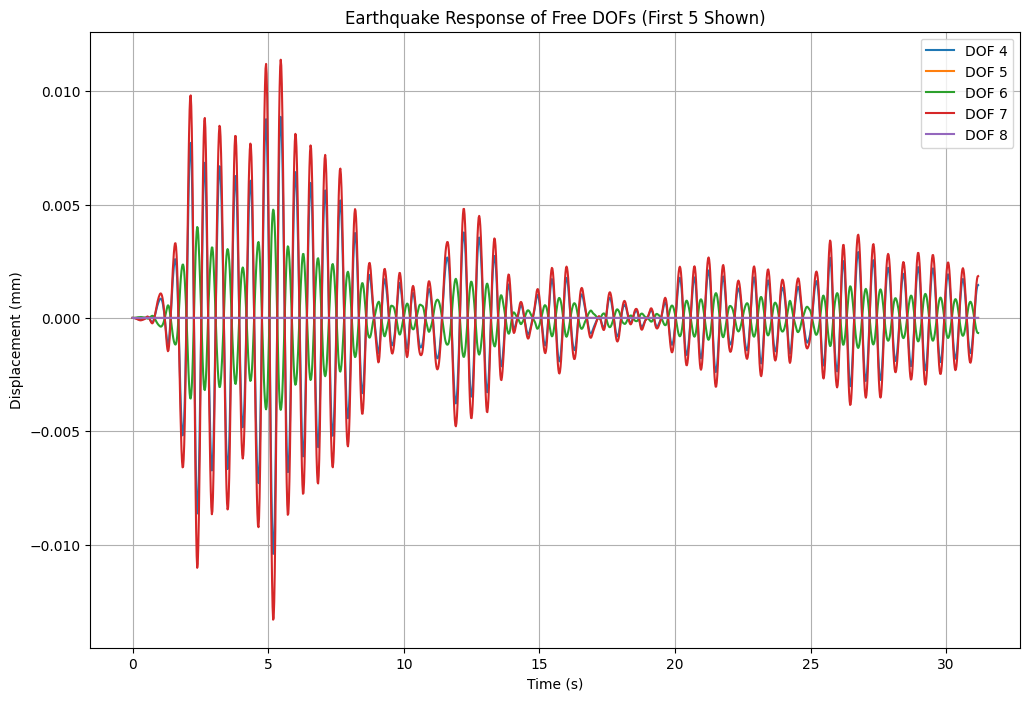


=== Enhanced Earthquake Response Animation ===

Maximum displacement: 0.0133 mm
Using scaling factor: 8000.00
Animating 1560 frames over 31.18 seconds


<ipython-input-17-6f1075ecb1e5>:514: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Rendering enhanced earthquake response animation...


In [ ]:
# MODE SHAPES AND RESPONSE OF A WARREN TYPE BRIDGE TRUSS DUE TO ELCENTRO GROUND MOTION

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from scipy.linalg import eigh
from scipy.integrate import trapezoid
from IPython.display import HTML

# Geometric inputs
elements = 36 # number of members
nodes = 18 # number of nodes
constraints = 10 # number of supports
force = nodes - constraints # number of free nodes
A = 100.0 # Area (mm2)
E = 100000.0 # Modulus of Elasticity (MPa)

# Initialize arrays
node_coordinates = np.zeros((nodes, 3))  # 3D coordinates (x, y, z)
element_connectivity = np.zeros((elements, 2), dtype=int) # corresponding nodes for each element
constraints_x_y_z = np.zeros((constraints, 4)) # constraints of each nodes
element_orientation = np.zeros((elements, 3)) # direction cosines of each element
element_length = np.zeros(elements) # length of each elements
element_stiffness_matrices = [] # Initiating element's stiffness matrix
element_mass_matrices = [] # Initiating element's mass matrix
element_direction = np.zeros((elements, 6)) # numbering (x,y,z) directions for each node
global_stiffness_matrix = np.zeros((3*nodes, 3*nodes)) # global stiffness matrix
global_mass_matrix = np.zeros((3*nodes, 3*nodes)) # global mass matrix

# Node Coordinates in mm
node_coordinates[0] = [0, 1000, 0]          # Node 1
node_coordinates[1] = [500, 1000, 866]      # Node 2
node_coordinates[2] = [1000, 1000, 0]       # Node 3
node_coordinates[3] = [1500, 1000, 866]     # Node 4
node_coordinates[4] = [2000, 1000, 0]       # Node 5
node_coordinates[5] = [2500, 1000, 866]     # Node 6
node_coordinates[6] = [3000, 1000, 0]       # Node 7
node_coordinates[7] = [3500, 1000, 866]     # Node 8
node_coordinates[8] = [4000, 1000, 0]       # Node 9
node_coordinates[9] = [0, 0, 0]             # Node 10
node_coordinates[10] = [500, 0, 866]        # Node 11
node_coordinates[11] = [1000, 0, 0]         # Node 12
node_coordinates[12] = [1500, 0, 866]       # Node 13
node_coordinates[13] = [2000, 0, 0]         # Node 14
node_coordinates[14] = [2500, 0, 866]       # Node 15
node_coordinates[15] = [3000, 0, 0]         # Node 16
node_coordinates[16] = [3500, 0, 866]       # Node 17
node_coordinates[17] = [4000, 0, 0]         # Node 18

# Define Element Connectivity
element_connectivity[0] = [1, 2]     # Start End Nodes of Member 1
element_connectivity[1] = [3, 2]     # Start End Nodes of Member 2
element_connectivity[2] = [1, 2]     # Start End Nodes of Member 3
element_connectivity[3] = [3, 4]     # Start End Nodes of Member 4
element_connectivity[4] = [5, 4]     # Start End Nodes of Member 5
element_connectivity[5] = [3, 5]     # Start End Nodes of Member 6
element_connectivity[6] = [5, 6]     # Start End Nodes of Member 7
element_connectivity[7] = [7, 6]     # Start End Nodes of Member 8
element_connectivity[8] = [5, 7]     # Start End Nodes of Member 9
element_connectivity[9] = [7, 8]     # Start End Nodes of Member 10
element_connectivity[10] = [9, 8]    # Start End Nodes of Member 11
element_connectivity[11] = [7, 9]    # Start End Nodes of Member 12
element_connectivity[12] = [10, 11]  # Start End Nodes of Member 13
element_connectivity[13] = [12, 11]  # Start End Nodes of Member 14
element_connectivity[14] = [10, 12]  # Start End Nodes of Member 15
element_connectivity[15] = [12, 13]  # Start End Nodes of Member 16
element_connectivity[16] = [14, 13]  # Start End Nodes of Member 17
element_connectivity[17] = [12, 14]  # Start End Nodes of Member 18
element_connectivity[18] = [14, 15]  # Start End Nodes of Member 19
element_connectivity[19] = [16, 15]  # Start End Nodes of Member 20
element_connectivity[20] = [14, 16]  # Start End Nodes of Member 21
element_connectivity[21] = [16, 17]  # Start End Nodes of Member 22
element_connectivity[22] = [18, 17]  # Start End Nodes of Member 23
element_connectivity[23] = [16, 18]  # Start End Nodes of Member 24
element_connectivity[24] = [1, 10]   # Start End Nodes of Member 25
element_connectivity[25] = [9, 18]   # Start End Nodes of Member 26
element_connectivity[26] = [2, 11]   # Start End Nodes of Member 27
element_connectivity[27] = [4, 13]   # Start End Nodes of Member 28
element_connectivity[28] = [6, 15]   # Start End Nodes of Member 29
element_connectivity[29] = [8, 17]   # Start End Nodes of Member 30
element_connectivity[30] = [2, 4]    # Start End Nodes of Member 31
element_connectivity[31] = [4, 6]    # Start End Nodes of Member 32
element_connectivity[32] = [6, 8]    # Start End Nodes of Member 33
element_connectivity[33] = [11, 13]  # Start End Nodes of Member 34
element_connectivity[34] = [13, 15]  # Start End Nodes of Member 35
element_connectivity[35] = [15, 17]  # Start End Nodes of Member 36

# Defining Constraints
# Fixed supports at nodes 1, 9, 10, 18
constraints_x_y_z[0] = [1, 1, 1, 1]
constraints_x_y_z[1] = [9, 1, 1, 1]
constraints_x_y_z[2] = [10, 1, 1, 1]
constraints_x_y_z[3] = [18, 1, 1, 1]
# Roller supports at nodes 3, 5, 7, 12, 14, 16
constraints_x_y_z[4] = [3, 0, 0, 1]  # Node 13 fixed in x
constraints_x_y_z[5] = [5, 0, 0, 1]  # Node 18 fixed in x
constraints_x_y_z[6] = [7, 0, 0, 1]  # Node 2 fixed in z
constraints_x_y_z[7] = [12, 0, 0, 1]  # Node 5 fixed in z
constraints_x_y_z[8] = [14, 0, 0, 1]  # Node 8 fixed in z
constraints_x_y_z[9] = [16, 0, 0, 1]  # Node 11 fixed in z

# Loop to get element directions
dof = np.arange(1, 3*nodes+1)
directions = dof.reshape(-1, 3)
for i in range(elements):
  n1, n2 = element_connectivity[i]
  a, b, c = directions[n1-1]
  d, e, f = directions[n2-1]
  element_direction[i] = [a-1, b-1, c-1, d-1, e-1, f-1]

# Loop to calculate length, orientation and stiffness of each element
for i in range(elements):
  # Extracting Coordinates
  n1, n2 = element_connectivity[i]
  x1, y1, z1 = node_coordinates[n1-1]
  x2, y2, z2 = node_coordinates[n2-1]

  # Finding Length and Orientation
  L = round(np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2), 2)
  cos_x = (x2-x1) / L
  cos_y = (y2-y1) / L
  cos_z = (z2-z1) / L
  element_length[i] = L
  element_orientation[i] = [cos_x, cos_y, cos_z]

  # Compute element stiffness matrix
  k = (E * A / L) * np.array([
      [cos_x**2    , cos_x*cos_y , cos_x*cos_z , -cos_x**2   , -cos_x*cos_y, -cos_x*cos_z],
      [cos_x*cos_y , cos_y**2    , cos_y*cos_z , -cos_x*cos_y, -cos_y**2   , -cos_y*cos_z],
      [cos_x*cos_z , cos_y*cos_z , cos_z**2    , -cos_x*cos_z, -cos_y*cos_z, -cos_z**2   ],
      [-cos_x**2   , -cos_x*cos_y, -cos_x*cos_z, cos_x**2    , cos_x*cos_y , cos_x*cos_z ],
      [-cos_x*cos_y, -cos_y**2   , -cos_y*cos_z, cos_x*cos_y , cos_y**2    , cos_y*cos_z ],
      [-cos_x*cos_z, -cos_y*cos_z, -cos_z**2   , cos_x*cos_z , cos_y*cos_z , cos_z**2    ]
    ])

  # Compute element mass matrix
  sigma = 0.005 # mass per unit length (kg/mm)
  m = (sigma * L / 6.0) * np.array([
      [2.0, 0.0, 0.0, 1.0, 0.0, 0.0],
      [0.0, 2.0, 0.0, 0.0, 1.0, 0.0],
      [0.0, 0.0, 2.0, 0.0, 0.0, 1.0],
      [1.0, 0.0, 0.0, 2.0, 0.0, 0.0],
      [0.0, 1.0, 0.0, 0.0, 2.0, 0.0],
      [0.0, 0.0, 1.0, 0.0, 0.0, 2.0]
  ])

  # Store the stiffness matrix
  element_stiffness_matrices.append(k)
  element_mass_matrices.append(m)

# Generating Global Stiffness Matrix
for i in range(elements):
  indices = element_direction[i]
  for j in range(6):
    for k in range(6):
        global_stiffness_matrix[int(indices[j]), int(indices[k])] += round(element_stiffness_matrices[i][j, k], 3)
        global_mass_matrix[int(indices[j]), int(indices[k])] += round(element_mass_matrices[i][j, k], 3)

# Seggregating known and unknown dofs
constrained_dofs = []
free_dofs = []

# First identify all constrained DOFs
for i in range(constraints):
    node, x, y, z = constraints_x_y_z[i]
    node_idx = int(node) - 1  # convert to 0-based
    if x == 1: constrained_dofs.append(3*node_idx)
    if y == 1: constrained_dofs.append(3*node_idx + 1)
    if z == 1: constrained_dofs.append(3*node_idx + 2)

# Then free DOFs are all others
all_dofs = set(range(3*nodes))
free_dofs = sorted(list(all_dofs - set(constrained_dofs)))

# Calculating Degree of Static Indeterminacy
Ds = elements + len(constrained_dofs) - 3 * nodes
if Ds != 0:
  raise Exception("Degree of Static Indeterminacy is not zero")

# Ensure free_dofs isn't empty
if not free_dofs:
    raise ValueError("No free degrees of freedom! Check your constraints.")

# Extracting Sub Matrix for free DOFs of Stiffness and Mass
K = global_stiffness_matrix[free_dofs, :][:, free_dofs]
M = global_mass_matrix[free_dofs, :][:, free_dofs]

# Add small regularization to stiffness matrix
K_reg = K + 1e-6 * np.max(np.diag(K)) * np.eye(K.shape[0])

# Number of modes to skip (rigid body and near-zero modes)
n_modes_to_skip = 10

# Solve eigenvalue problem, skipping first n_modes_to_skip modes
total_eigenvalues, total_phi = eigh(K, M)
eigenvalues, phi = eigh(K_reg, M,
                       subset_by_index=[n_modes_to_skip, len(free_dofs)-1])

# Filter out negative and near-zero eigenvalues
valid_indices = eigenvalues > 1e-6
eigenvalues = eigenvalues[valid_indices]
phi = phi[:, valid_indices]

# Calculate frequencies
wn = np.sqrt(eigenvalues)  # Natural frequencies (rad/s)
fn = wn / (2 * np.pi)      # Natural frequencies (Hz)

print("\nEigenvalues:")
print(total_eigenvalues)

print("\nValid Natural Frequencies (Hz):")
for i, freq in enumerate(fn):
    print(f"Mode {i+1+n_modes_to_skip}: {freq:.3f} Hz")

# Modal Mass and Stiffness
Md = phi.T @ M @ phi
Kd = phi.T @ K @ phi

# Solve for modal damping using only valid modes
if len(fn) >= 2:  # Need at least 2 modes for damping calculation
    A = np.array([
        [1/(2*wn[0]), wn[0]/2],
        [1/(2*wn[1]), wn[1]/2]
    ])

    xi_1 = 0.02
    xi_2 = 0.02

    xi_n = np.array([[xi_1], [xi_2]])
    ab = np.linalg.inv(A) @ xi_n
    C = ab[0] * M + ab[1] * K
    Cd = phi.T @ C @ phi

    # Modal Damping Ratio
    eta_n = np.diag(Cd) / (2 * wn)
    print("\nModal Damping Ratios:")
    print(eta_n)
else:
    print("\nWarning: Not enough valid modes for damping calculation")
    eta_n = np.ones(len(fn)) * 0.02  # Default damping

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File path in Google Drive
file_path = "/content/drive/My Drive/ELcentro_Accelaration_data.txt"

# Load data using pandas
df = pd.read_csv(file_path, delimiter="\t", header=None, names=["Time", "Acceleration"])

# Convert columns to arrays
time = df["Time"].values
xg_ddt = df["Acceleration"].values

# Earthquake excitation vector (assuming uniform excitation in all horizontal directions)
# Create influence vector that only affects x-direction DOFs
ifl = np.zeros((len(free_dofs),1))
for i, dof in enumerate(free_dofs):
    if dof % 3 == 0:  # Only x-direction DOFs (0, 3, 6, ...)
        ifl[i] = -1.0
F = M @ ifl  # Effective earthquake force
F_n = phi.T @ F  # Modal forces

def Duhamel_Integral(m, k, eta, t, f_t):
    """Computes the response using Duhamel's Integral via Trapezoidal Integration."""
    wn = np.sqrt(k / m)
    wd = wn * np.sqrt(1 - eta**2)
    nt = len(t)
    x_t = np.zeros(nt)

    for ii in range(1, nt):
        t_0 = t[0]
        t_st = t[ii]
        tau = t[:ii+1]
        f_tau = f_t[:ii+1]

        f1 = np.exp(eta * wn * tau) * np.cos(wd * tau) * f_tau
        f2 = np.exp(eta * wn * tau) * np.sin(wd * tau) * f_tau

        A_tau = trapezoid(f1, tau)
        B_tau = trapezoid(f2, tau)

        x_t[ii] = (1 / (m * wd)) * np.exp(-eta * wn * t_st) * (A_tau * np.sin(wd * t_st) - B_tau * np.cos(wd * t_st))

    return x_t

# Compute modal responses using only valid modes
num_modes = len(wn)
Z_n = np.zeros((num_modes, len(time)))

for i in range(num_modes):  # Loop over valid modes only
    Z_n[i, :] = Duhamel_Integral(1, wn[i]**2, eta_n[i], time, F_n[i] * xg_ddt)

# Transform back to physical coordinates (relative displacement)
X_t = phi @ Z_n  # X_t is relative displacement of free DOFs

# Print the filtered matrices
print("\nFiltered Eigenvalues:")
print(eigenvalues)
print("\nFiltered Phi matrix shape:", phi.shape)
print("\nFiltered Modal Mass Matrix:")
print(Md)
print("\nFiltered Modal Stiffness Matrix:")
print(Kd)
print("\nFiltered Modal Damping Matrix:")
print(Cd)

# Set higher animation embed limit (in MB)
plt.rcParams['animation.embed_limit'] = 500  # Increase to 500MB

# Plot El Centro ground motion
plt.figure(figsize=(12, 6))
plt.plot(time, xg_ddt, 'b-', linewidth=1.5)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Acceleration (g)', fontsize=12)
plt.title('El Centro Earthquake Ground Motion (1940)', fontsize=14)
plt.grid(True)
plt.show()

# Plot the response of the first few DOFs
plt.figure(figsize=(12, 8))
for i in range(min(5, len(free_dofs))):  # Only plot first 5 DOFs for clarity
    plt.plot(time, X_t[i, :], label=f'DOF {free_dofs[i]+1}')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (mm)')
plt.title('Earthquake Response of Free DOFs (First 5 Shown)')
plt.legend()
plt.grid(True)
plt.show()

# EARTHQUAKE RESPONSE ANIMATION
def animate_earthquake_response():
    # Create figure
    fig = plt.figure(figsize=(24, 18), constrained_layout=True)

    # Create gridspec layout - 3D view on top, DOF plots below in multiple rows
    gs = gridspec.GridSpec(6, 2, height_ratios=[1.5, 1, 1, 1, 1, 1], wspace=0.3, hspace=0.8)

    # Calculate maximum displacement for scaling
    max_disp = np.max(np.abs(X_t))
    print(f"\nMaximum displacement: {max_disp:.4f} mm")

    # Automatic scaling factor - make it more sensitive to small displacements
    structure_size = np.max(node_coordinates) - np.min(node_coordinates)
    scale = 0.5 * structure_size / (max_disp if max_disp > 1e-3 else 1)  # More aggressive scaling

    # Adjust scale if too small or too large
    min_scale = 0.1 * structure_size
    max_scale = 2.0 * structure_size
    scale = np.clip(scale, min_scale, max_scale)
    print(f"Using scaling factor: {scale:.2f}")

    # Create 3D structure subplot at the top spanning both columns
    ax_3d = plt.subplot(gs[0, :], projection='3d')
    ax_3d.set_title("3D Structure Response (Deformation scaled by %.1fx)" % (scale/structure_size),
                   fontsize=14, pad=20)

    # Initialize 3D structure lines
    original_lines = []
    deformed_lines = []
    for elem in element_connectivity:
        orig_line, = ax_3d.plot([], [], [], 'k-', alpha=0.3, linewidth=1.5)
        def_line, = ax_3d.plot([], [], [], 'r-', linewidth=3)
        original_lines.append(orig_line)
        deformed_lines.append(def_line)

    # Set 3D axis limits - tighter bounds based on actual structure dimensions
    x_min, x_max = node_coordinates[:,0].min(), node_coordinates[:,0].max()
    y_min, y_max = node_coordinates[:,1].min(), node_coordinates[:,1].max()
    z_min, z_max = node_coordinates[:,2].min(), node_coordinates[:,2].max()

    # Calculate tight bounds with minimal padding
    x_center, y_center, z_center = (x_min+x_max)/2, (y_min+y_max)/2, (z_min+z_max)/2
    x_range, y_range, z_range = x_max-x_min, y_max-y_min, z_max-z_min

    # Use 10% padding but ensure minimum padding of 100mm
    padding = max(100, 0.1 * max(x_range, y_range, z_range))

    ax_3d.set_xlim(x_center-padding, x_center+padding)
    ax_3d.set_ylim(y_center-padding, y_center+padding)
    ax_3d.set_zlim(z_center-padding, z_center+padding)

    ax_3d.set_xlabel('X (mm)', fontsize=12, labelpad=10)
    ax_3d.set_ylabel('Y (mm)', fontsize=12, labelpad=10)
    ax_3d.set_zlabel('Z (mm)', fontsize=12, labelpad=10)
    ax_3d.grid(True)
    ax_3d.view_init(elev=35, azim=45)  # Better viewing angle

    # Create time text
    time_text = ax_3d.text2D(0.02, 0.95, '', transform=ax_3d.transAxes,
                           fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

    # Create displacement-time subplots in the remaining rows - limit to first 10 DOFs
    num_dofs_to_show = min(10, len(free_dofs))  # Show max 10 DOFs (5 rows x 2 columns)
    displacement_plots = []
    displacement_lines = []
    marker_lines = []
    time_markers = []

    # Create a subplot for each DOF response
    for i in range(num_dofs_to_show):
        # Determine grid position - we have 5 rows (1-5) and 2 columns (0,1) available
        row = (i // 2) + 1  # Rows 1-5
        col = i % 2          # Columns 0-1

        ax = plt.subplot(gs[row, col])

        # Calculate tight y-limits for this DOF
        y_min = np.min(X_t[i]) * 1.2
        y_max = np.max(X_t[i]) * 1.2
        y_padding = max(0.1 * (y_max - y_min), 0.1)  # Ensure some padding

        ax.set_xlim(time[0], time[-1])
        ax.set_ylim(y_min - y_padding, y_max + y_padding)
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel('Disp (mm)', fontsize=10)
        ax.grid(True, alpha=0.5)

        # Main response line
        line, = ax.plot([], [], 'b-', lw=1.5, alpha=0.8)

        # Current position marker
        marker, = ax.plot([], [], 'ro', markersize=6)

        # Time marker line
        time_marker = ax.axvline(0, color='r', linestyle='--', alpha=0.5)

        displacement_plots.append(ax)
        displacement_lines.append(line)
        marker_lines.append(marker)
        time_markers.append(time_marker)

        ax.set_title(f'DOF {free_dofs[i]+1} Response', fontsize=12, pad=10)
        ax.tick_params(axis='both', which='major', labelsize=9)

    # Initialize function
    def init():
        # Initialize displacement plots
        for line, marker in zip(displacement_lines, marker_lines):
            line.set_data([], [])
            marker.set_data([], [])

        for marker in time_markers:
            marker.set_xdata([0, 0])

        # Initialize 3D structure
        for i, elem in enumerate(element_connectivity):
            n1, n2 = elem
            x = [node_coordinates[n1-1,0], node_coordinates[n2-1,0]]
            y = [node_coordinates[n1-1,1], node_coordinates[n2-1,1]]
            z = [node_coordinates[n1-1,2], node_coordinates[n2-1,2]]
            original_lines[i].set_data(x, y)
            original_lines[i].set_3d_properties(z)
            deformed_lines[i].set_data(x, y)
            deformed_lines[i].set_3d_properties(z)

        time_text.set_text('Time: 0.00 s')
        return displacement_lines + marker_lines + time_markers + original_lines + deformed_lines + [time_text]

    # Increase frame rate by using more time steps
    step = max(1, len(time) // 200)  # Targeting ~200 frames for very smooth animation
    time_indices = np.arange(0, len(time), step)
    print(f"Animating {len(time_indices)} frames over {time[-1]:.2f} seconds")

    # Update function - only update the DOFs we're showing
    def update(frame):
        time_idx = time_indices[frame]
        current_time = time[time_idx]

        # Update displacement plots
        for i, (line, marker, t_marker) in enumerate(zip(displacement_lines, marker_lines, time_markers)):
            line.set_data(time[:time_idx+1], X_t[i,:time_idx+1])
            marker.set_data([current_time], [X_t[i, time_idx]])
            t_marker.set_xdata([current_time, current_time])

        # Update 3D structure with more visible deformation
        displacement = np.zeros(3*nodes)
        displacement[free_dofs] = X_t[:, time_idx]

        for i, elem in enumerate(element_connectivity):
            n1, n2 = elem
            x1, y1, z1 = node_coordinates[n1-1]
            x2, y2, z2 = node_coordinates[n2-1]

            dx1 = scale * displacement[3*(n1-1)]
            dy1 = scale * displacement[3*(n1-1)+1]
            dz1 = scale * displacement[3*(n1-1)+2]

            dx2 = scale * displacement[3*(n2-1)]
            dy2 = scale * displacement[3*(n2-1)+1]
            dz2 = scale * displacement[3*(n2-1)+2]

            deformed_lines[i].set_data(
                [x1 + dx1, x2 + dx2],
                [y1 + dy1, y2 + dy2]
            )
            deformed_lines[i].set_3d_properties(
                [z1 + dz1, z2 + dz2]
            )

        time_text.set_text(f'Time: {current_time:.2f} s')
        return displacement_lines + marker_lines + time_markers + deformed_lines + [time_text]

    # Create animation with higher frame rate
    ani = FuncAnimation(
        fig, update, frames=len(time_indices), init_func=init,
        interval=16, blit=True, repeat=True  # ~60fps (1000/16 ≈ 60)
    )

    plt.close()
    print("\nRendering enhanced earthquake response animation...")
    display(HTML(ani.to_jshtml()))

# Execute enhanced earthquake response animation
print("\n=== Enhanced Earthquake Response Animation ===")
animate_earthquake_response()

# MODE SHAPE VISUALIZATION AND ANIMATION
def animate_mode_shapes():
    num_modes = len(fn)  # Use only valid modes

    for mode in range(num_modes):
        actual_mode_number = mode + n_modes_to_skip + 1
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_title(f"Mode {actual_mode_number} - Frequency: {fn[mode]:.3f} Hz", fontsize=12)

        # Initialize lines
        original_lines = []
        deformed_lines = []
        for elem in element_connectivity:
            orig_line, = ax.plot([], [], [], 'k--', alpha=0.5, linewidth=1)
            def_line, = ax.plot([], [], [], 'r-', linewidth=3)
            original_lines.append(orig_line)
            deformed_lines.append(def_line)

        # Reconstruct full mode shape
        full_mode = np.zeros(3*nodes)
        full_mode[free_dofs] = phi[:,mode]

        # Calculate scaling factor automatically
        max_disp = np.max(np.abs(full_mode))
        scale = 0.2 * np.max(node_coordinates) / (max_disp if max_disp > 0 else 1)

        # Set axis limits
        all_coords = node_coordinates.flatten()
        coord_range = max(all_coords.max() - all_coords.min(), 1)
        padding = 0.2 * coord_range

        ax.set_xlim(node_coordinates[:,0].min()-padding, node_coordinates[:,0].max()+padding)
        ax.set_ylim(node_coordinates[:,1].min()-padding, node_coordinates[:,1].max()+padding)
        ax.set_zlim(node_coordinates[:,2].min()-padding, node_coordinates[:,2].max()+padding)

        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')

        def init():
            """Initialize the animation"""
            for i, elem in enumerate(element_connectivity):
                n1, n2 = elem
                # Original structure
                x = [node_coordinates[n1-1,0], node_coordinates[n2-1,0]]
                y = [node_coordinates[n1-1,1], node_coordinates[n2-1,1]]
                z = [node_coordinates[n1-1,2], node_coordinates[n2-1,2]]
                original_lines[i].set_data(x, y)
                original_lines[i].set_3d_properties(z)

                # Initial deformed position (same as original)
                deformed_lines[i].set_data(x, y)
                deformed_lines[i].set_3d_properties(z)

            return original_lines + deformed_lines

        def update(frame):
            time = frame / 10  # Slower animation
            displacement_factor = np.sin(2 * np.pi * time) * scale

            for i, elem in enumerate(element_connectivity):
                n1, n2 = elem

                # Original coordinates
                x1, y1, z1 = node_coordinates[n1-1]
                x2, y2, z2 = node_coordinates[n2-1]

                # Add scaled modal displacement
                dx1 = displacement_factor * full_mode[3*(n1-1)]
                dy1 = displacement_factor * full_mode[3*(n1-1)+1]
                dz1 = displacement_factor * full_mode[3*(n1-1)+2]

                dx2 = displacement_factor * full_mode[3*(n2-1)]
                dy2 = displacement_factor * full_mode[3*(n2-1)+1]
                dz2 = displacement_factor * full_mode[3*(n2-1)+2]

                # Update deformed lines
                deformed_lines[i].set_data(
                    [x1 + dx1, x2 + dx2],
                    [y1 + dy1, y2 + dy2]
                )
                deformed_lines[i].set_3d_properties(
                    [z1 + dz1, z2 + dz2]
                )

            return deformed_lines

        # Create animation
        ani = FuncAnimation(
            fig, update, frames=30, init_func=init,
            interval=50, blit=True, repeat=True
        )

        plt.close()
        print(f"\nMode {actual_mode_number} Animation - Scaling Factor: {scale:.2f}")
        display(HTML(ani.to_jshtml()))

# Execute the animation
print("\n=== Mode Shape Animations ===")
animate_mode_shapes()